In [14]:
# data_exploration.ipynb

# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For modeling later
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# modeling used
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Display settings
pd.set_option('display.max_columns', None)


In [15]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Soura\Downloads\all_teams.csv")
print("Shape:", df.shape)
df.head()

Shape: (222180, 111)


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame
0,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,other,0.0000,0.0000,0.0000,42.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.689,0.019,0.069,0.164,0.020,0.521,0.207,0.019,0.019,0.019,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.019,0.000,0.000,0.0,0.0,0.0,1.00,1.0,1.000,0.0,0.017,0.000,0.000,0.037,0.037,0.037,0
1,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,all,0.4596,0.6408,0.6310,3600.0,37.733,2.287,2.842,8.155,1.134,22.530,16.054,2.249,2.396,2.357,41.0,12.0,13.0,66.0,2.0,1.0,0.0,14.0,2.0,18.0,16.0,39.0,51.0,4.0,8.0,30.0,16.0,19.0,8.0,44.0,8.0,1.0,1.040,0.811,0.435,1.0,0.0,1.0,68.292,53.0,54.697,4.0,0.641,0.014,0.029,2.899,3.030,2.980,22.880,2.689,1.780,4.436,0.639,12.626,8.830,2.524,2.607,2.450,21.0,10.0,6.0,37.0,1.0,1.0,0.0,5.0,1.0,8.0,15.0,20.0,30.0,7.0,14.0,32.0,17.0,11.0,7.0,16.0,12.0,3.0,0.599,1.278,0.811,1.0,0.0,0.0,36.14,31.0,30.369,5.0,0.396,0.168,0.168,2.917,2.833,2.714,0
2,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,5on5,0.4857,0.6429,0.6364,2283.0,24.802,1.693,1.724,5.513,0.739,14.650,10.681,1.656,1.803,1.764,28.0,7.0,10.0,45.0,1.0,0.0,0.0,10.0,1.0,14.0,9.0,27.0,34.0,3.0,6.0,19.0,13.0,13.0,7.0,27.0,8.0,0.0,0.882,0.811,0.000,1.0,0.0,0.0,47.292,35.0,36.697,4.0,0.355,0.000,0.000,2.048,2.180,2.130,14.729,1.793,1.117,3.001,0.406,7.737,5.946,1.633,1.711,1.559,11.0,9.0,5.0,25.0,1.0,1.0,0.0,4.0,1.0,4.0,9.0,10.0,19.0,7.0,14.0,18.0,13.0,9.0,5.0,12.0,6.0,2.0,0.498,0.689,0.606,1.0,0.0,0.0,24.14,20.0,19.369

In [16]:
# Explore Columns
df.info()
df.describe().T.head(10)

# check sample columns
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222180 entries, 0 to 222179
Columns: 111 entries, team to playoffGame
dtypes: float64(100), int64(4), object(7)
memory usage: 188.2+ MB


['team',
 'season',
 'name',
 'gameId',
 'playerTeam',
 'opposingTeam',
 'home_or_away',
 'gameDate',
 'position',
 'situation',
 'xGoalsPercentage',
 'corsiPercentage',
 'fenwickPercentage',
 'iceTime',
 'xOnGoalFor',
 'xGoalsFor',
 'xReboundsFor',
 'xFreezeFor',
 'xPlayStoppedFor',
 'xPlayContinuedInZoneFor',
 'xPlayContinuedOutsideZoneFor',
 'flurryAdjustedxGoalsFor',
 'scoreVenueAdjustedxGoalsFor',
 'flurryScoreVenueAdjustedxGoalsFor',
 'shotsOnGoalFor',
 'missedShotsFor',
 'blockedShotAttemptsFor',
 'shotAttemptsFor',
 'goalsFor',
 'reboundsFor',
 'reboundGoalsFor',
 'freezeFor',
 'playStoppedFor',
 'playContinuedInZoneFor',
 'playContinuedOutsideZoneFor',
 'savedShotsOnGoalFor',
 'savedUnblockedShotAttemptsFor',
 'penaltiesFor',
 'penalityMinutesFor',
 'faceOffsWonFor',
 'hitsFor',
 'takeawaysFor',
 'giveawaysFor',
 'lowDangerShotsFor',
 'mediumDangerShotsFor',
 'highDangerShotsFor',
 'lowDangerxGoalsFor',
 'mediumDangerxGoalsFor',
 'highDangerxGoalsFor',
 'lowDangerGoalsFor',
 '

In [17]:
# Feature Engineering

# Target variable: 1 = Win, 0 = Loss
df['win'] = (df['goalsFor'] > df['goalsAgainst']).astype(int)

# Merge Arizona with Utah due to the team relocation
df['team'] = df['team'].replace({'ARI': 'UTA'})

# Filter to keep only seasons from 2022 onward
df_recent = df[df['season'] >= 2022].reset_index(drop=True)
print("Filtered recent seasons (>= 2022):", len(df_recent))
print("Unique seasons:", df_recent['season'].unique())

# From the recent data, select only rows where situation == 'all'
df_all = df_recent[df_recent['situation'] == 'all'].reset_index(drop=True)
print("\nRows with situation == 'all':", len(df_all))
print("Unique games before cleanup:", df_all['gameId'].nunique())

# Detect and remove bad games, each game should have exactly one winner
game_win_sums = df_all.groupby('gameId')['win'].sum()

# Identify invalid games
bad_game_ids = game_win_sums[game_win_sums != 1].index
print("Bad games detected:", len(bad_game_ids))

# Remove invalid games
df_all = df_all[~df_all['gameId'].isin(bad_game_ids)].reset_index(drop=True)

# Print cleanup summary
print("\n✅ After cleanup:")
print("Total rows:", len(df_all))
print("Unique games:", df_all['gameId'].nunique())
print("Win counts:\n", df_all['win'].value_counts())

# Create performance difference features
df_all['shot_diff'] = df_all['shotsOnGoalFor'] - df_all['shotsOnGoalAgainst']
df_all['penalty_diff'] = df_all['penaltiesFor'] - df_all['penaltiesAgainst']
df_all['shotAttempt_diff'] = df_all['shotAttemptsFor'] - df_all['shotAttemptsAgainst']
df_all['faceOff_diff'] = df_all['faceOffsWonFor'] - df_all['faceOffsWonAgainst']


# Export cleaned DataFrames to ../data/processed/
df_recent.to_csv('../data/processed/recent_teams.csv', index=False)
df_all.to_csv('../data/processed/processed_teams.csv', index=False)

print("\n Saved both files to ../data/processed/:")
print(" - recent_teams.csv  → all data since 2022")
print(" - processed_teams.csv → cleaned + situation == 'all'")

# Preview cleaned data
df_all.head()


Filtered recent seasons (>= 2022): 45880
Unique seasons: [2022 2023 2024 2025]

Rows with situation == 'all': 9176
Unique games before cleanup: 4588
Bad games detected: 290

✅ After cleanup:
Total rows: 8596
Unique games: 4298
Win counts:
 win
1    4298
0    4298
Name: count, dtype: int64


OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [ ]:
df_grouped = df.groupby('team')['win'].sum().reset_index().sort_values(by='win', ascending=False)

df_grouped.plot.bar(x='team', y='win')
plt.show()

In [ ]:
# Exploratory Analysis

# Count wins and losses
win_count = (df_all['win'] == 1).astype(int).sum()
loss_count = (df_all['win'] == 0).astype(int).sum()
print(f"Wins: {win_count}, Losses: {loss_count}")

# Values
categories = ['Win', 'Loss']
counts = [win_count, loss_count]

# Plot
plt.bar(categories, counts, color=['green', 'red'])
plt.title('Number of Wins vs Losses')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

In [ ]:
#Final sanity checks

# Check unique teams in recent data
current_teams = df_all['team'].unique()
print("Number of unique teams:", len(current_teams))
print("Teams:", sorted(current_teams))

# Display win counts per team
print(df_all.groupby('team')['win'].agg(['sum', 'count']))

# Check for any NaN values in recent data
print("Any NaNs?", df_all.isna().sum().sum())

# Check for duplicated game-team entries in cleaned data
dup_games = df_all[df_all.duplicated(['gameId', 'team'])]
print("Duplicated rows:", len(dup_games))

In [ ]:
# Correlation heat maps
corr = df_all[['win','shotsOnGoalFor','penaltiesFor', 'faceOffsWonFor', 'shotAttemptsFor', 'blockedShotAttemptsFor', 'lowDangerShotsFor', 'mediumDangerShotsFor', 'highDangerShotsFor']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
fig, ax = plt.figure(figsize=(10,8))


In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax[0,0].scatter(df_all['win'], df_all['lowDangerShotsFor'])
ax[0,1].scatter(df_all['win'], df_all['shotAttemptsFor'])
ax[1,0].scatter(df_all['win'], df_all['shotsOnGoalFor'])
ax[1,1].scatter(df_all['win'], df_all['faceOffsWonFor'])

ax[0,0].set_xlabel('lowDangerShotsFor')
ax[0,1].set_xlabel('shotAttemptsFor')
ax[0,0].set_xlabel('shotsOnGoalFor')
ax[1,1].set_xlabel('faceOffsWonFor')

In [ ]:
print(df_all.shape)

In [ ]:
X = df_all.loc[:,['highDangerShotsFor', 'mediumDangerShotsFor', 'lowDangerShotsFor', 'shotAttemptsFor', 'shotsOnGoalFor', 'faceOffsWonFor', 'penaltiesFor', 'blockedShotAttemptsFor']]
y = df_all['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# ------ ARYAN CODE BELOW --------

In [18]:
# This uses raw data, before aggregating them into averages. Likely not accurate, we wouldn't have this information for new games
from sklearn.model_selection import cross_val_score

df_all = pd.read_csv("C:\Users\Soura\Downloads\all_teams.csv")
X = df_all.loc[:,['highDangerShotsFor', 'mediumDangerShotsFor', 'lowDangerShotsFor', 'shotAttemptsFor', 'shotsOnGoalFor', 'faceOffsWonFor', 'penaltiesFor', 'blockedShotAttemptsFor',
                  'corsiPercentage', 'fenwickPercentage', 'shot_diff', 'shotAttempt_diff', 'xGoalsAgainst', 'xGoalsFor']]
y = df_all['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Feature importance
coefficients = lr.coef_[0]
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print(feature_importance)

scores = cross_val_score(lr, X, y, cv=5)
print(scores.mean())

train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print(train_score)
print(test_score)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1827889678.py, line 4)

Since the dataset utilizes exact values for each game, we calculate the average of the (important) features for the model to use for predictions, as we wouldn't have the actual values before the match we would want to predict. 
We also split each feature up into different windows so the model can learn whether more recent games are important, or overall stats:
- average of last 3 games
- average of last 5 games
- average of last 10 games
- average for all games in the season

In [19]:
# Sort by team and date first
df_avg = df_all.sort_values(['playerTeam', 'gameDate']).reset_index(drop=True)

# Average for a team's last 3 games average
df_avg['xGoalsFor_last3'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=3).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last3'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=3).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last3'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=3).mean().reset_index(0, drop=True)

# For a team's last 5 games average
df_avg['xGoalsFor_last5'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=5).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last5'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=5).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last5'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=5).mean().reset_index(0, drop=True)

# For a team's last 10 games average
df_avg['xGoalsFor_last10'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=10).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last10'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=10).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last10'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=10).mean().reset_index(0, drop=True)

# For season so far
df_avg['xGoalsFor_season'] = df_avg.groupby(['playerTeam', 'season'])['xGoalsFor'].transform(lambda x: x.expanding().mean().values)
df_avg['xshotsOnGoalFor_season'] = df_avg.groupby(['playerTeam', 'season'])['shotsOnGoalFor'].transform(lambda x: x.expanding().mean().values)
df_avg['xGoalsAgainst_season'] = df_avg.groupby(['playerTeam', 'season'])['xGoalsAgainst'].transform(lambda x: x.expanding().mean().values)

df_avg.head(10)

,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,shotAttempt_diff,faceOff_diff,xGoalsFor_last3,shotsOnGoalFor_last3,xGoalsAgainst_last3,xGoalsFor_last5,shotsOnGoalFor_last5,xGoalsAgainst_last5,xGoalsFor_last10,shotsOnGoalFor_last10,xGoalsAgainst_last10,xGoalsFor_season,xshotsOnGoalFor_season,xGoalsAgainst_season
0,ANA,2022,ANA,2022020009,ANA,SEA,HOME,20221012,Team Level,all,0.3188,0.3607,0.3404,3655.0,22.921,2.356,1.766,5.093,0.704,13.068,9.014,2.298,2.259,2.203,27.0,5.0,12.0,44.0,5.0,1.0,0.0,6.0,1.0,9.0,10.0,22.0,27.0,6.0,15.0,32.0,15.0,6.0,10.0,18.0,12.0,2.0,0.513,1.347,0.496,1.0,3.0,1.0,41.735,32.0,30.740,4.0,0.397,0.148,0.148,2.605,2.505,2.456,44.260,5.035,3.188,9.554,1.398,25.612,17.213,4.880,5.265,5.100,48.0,14.0,16.0,78.0,4.0,5.0,1.0,7.0,2.0,22.0,22.0,44.0,58.0,4.0,11.0,24.0,22.0,4.0,6.0,44.0,13.0,5.0,0.992,1.802,2.241,0.0,1.0,3.0,82.147,62.0,65.426,2.0,0.710,0.974,0.974,4.771,4.975,4.912,0,1,-21.0,2.0,-34.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.356000,27.000000,5.035000
1,ANA,2022,ANA,2022020032,ANA,NYI,AWAY,20221015,Team Level,all,0.3821,0.4560,0.4066,3600.0,26.321,2.389,1.956,6.403,0.942,14.901,10.409,2.280,2.357,2.250,23.0,14.0,20.0,57.0,1.0,5.0,0.0,7.0,1.0,16.0,7.0,22.0,36.0,5.0,10.0,28.0,14.0,2.0,9.0,26.0,10.0,1.0,0.773,1.275,0.341,0.0,1.0,0.0,54.505,37.0,36.172,5.0,0.441,0.955,0.955,1.874,1.852,1.808,36.594,3.863,2.766,8.732,1.316,22.821,14.502,3.692,3.869,3.697,38.0,16.0,14.0,68.0,7.0,4.0,1.0,9.0,2.0,13.0,19.0,31.0,47.0,5.0,10.0,37.0,18.0,6.0,19.0,40.0,11.0,3.0,1.383,1.408,1.072,5.0,0.0,2.0,71.918,54.0,55.413,8.0,0.594,1.063,1.063,3.394,3.425,3.351,0,0,-15.0,0.0,-11.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.372500,25.000000,4.449000
2,ANA,2022,ANA,2022020039,ANA,NYR,AWAY,202

Now that the features have been engineered, we can begin training our model. The workflow will go like this:
1) Split the data into 80/20, and leave the 20% for final testing after cross validation
2) Use a time-series cross validation approach to ensure that the model is not using information from the future. This prevents data leakage
3) Retrain the best model if needed
4) Evaluate model

In [20]:
X = df_avg[['xGoalsFor_last3', 'shotsOnGoalFor_last3', 'xGoalsAgainst_last3',
     'xGoalsFor_last5', 'shotsOnGoalFor_last5', 'xGoalsAgainst_last5',
     'xGoalsFor_last10', 'shotsOnGoalFor_last10', 'xGoalsAgainst_last10',
     'xGoalsFor_season', 'xshotsOnGoalFor_season', 'xGoalsAgainst_season']]
y = df_avg[['win']]

# Split the data into 80/20, preserving chronological order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# Some rows have NaN values, drop them
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(6633, 12)
(6633,)
(1666, 12)
(1666,)


In [21]:
# Try logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Check accuracy
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.6107342077491331
Test accuracy: 0.6014405762304922


In [22]:
# Try random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 1.0
Test accuracy: 0.5786314525810324


In [ ]:
SOURAV CODE 

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.73      0.69      4730
           1       0.64      0.55      0.59      4158

    accuracy                           0.65      8888
   macro avg       0.64      0.64      0.64      8888
weighted avg       0.65      0.65      0.64      8888

Confusion Matrix:
 [[3462 1268]
 [1883 2275]]


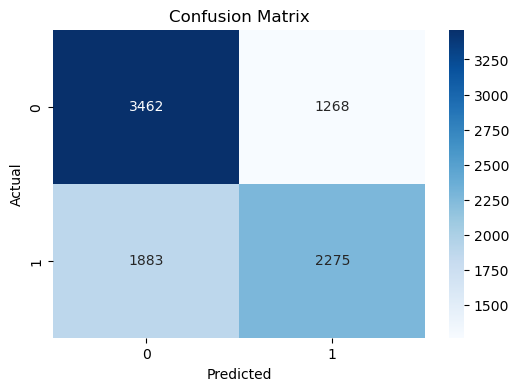

In [31]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\Soura\Downloads\all_teams.csv")

# Convert gameDate to datetime
df['gameDate'] = pd.to_datetime(df['gameDate'])


team_game_stats = df.groupby(['gameId', 'playerTeam']).agg({
    'xGoalsFor': 'mean',
    'shotsOnGoalFor': 'mean',
    'xGoalsAgainst': 'mean',
    'goalsFor': 'sum',
    'goalsAgainst': 'sum'
}).reset_index()


team_game_stats['win'] = (team_game_stats['goalsFor'] > team_game_stats['goalsAgainst']).astype(int)


features = ['xGoalsFor', 'shotsOnGoalFor', 'xGoalsAgainst']
target = 'win'

X = team_game_stats[features]
y = team_game_stats[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


y_pred = nb_model.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\Soura\Downloads\all_teams.csv")
print("Shape:", df.shape)
df.head()

print(df.columns.tolist())

features = [
    'xGoalsFor_last3', 'shotsOnGoalFor_last3', 'xGoalsAgainst_last3',
    'xGoalsFor_last5', 'shotsOnGoalFor_last5', 'xGoalsAgainst_last5',
    'xGoalsFor_last10', 'shotsOnGoalFor_last10', 'xGoalsAgainst_last10',
    'xGoalsFor_season', 'shotsOnGoalFor_season', 'xGoalsAgainst_season'  
]
target = 'win'

x = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred = nb_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Naive Bayes Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
